# Benchmark playground

Use the Python kernel from the `benchmark` environment. Install the repo with the `plot` extra before plotting.

This example compares VI and MPI on a small custom MDP and the catalogue `rooms` model.

In [1]:
from mdpforge import Benchmark

In [ ]:
bench = Benchmark()  # Includes VI.

models = [
    'access_control',
    'acrobot',
    'admission',
    'ambulance',
    'ambulance_relocation',
    'barto',
    'block',
    'blocks_world',
    'car_rental',
    'cartpole',
    'chain_walk',
    'cliff',
    'cliff_total',
    'dam',
    'elevator',
    'forest',
    'frozen',
    'gambler',
    'garnet',
    'hexagonal_grid_soccer',
    'impatience',
    'inventory',
    'inventory_leadtime',
    'local_perception_grid_world',
    'lqr',
    'm_maze',
    'maintenance',
    'maze_backtrack',
    'maze_prims',
    'maze_wilson',
    'mountain',
    'ninerooms',
    'office_world',
    'oil',
    'oil_discovery',
    'option_pricing',
    'peg_solitaire',
    'queue_network',
    'random_walk',
    'replacement',
    'rooms',
    'schoolboy',
    'sutton',
    'swim',
    'sysadmin',
    'tandem',
    'tandem_choice',
    'taxi',
    'tictactoe',
    'unichain',
    'windgrid',
    'wumpus_world',
]

solvers = [
    'aggregated_mpi',
    'aggregated_qvi',
    'aggregated_vi',
    'bertsekas_pi',
    'chen_td',
    'gurobi_dual',
    'gurobi_primal',
    'marmote_mpi',
    'marmote_mpigs',
    'marmote_vi',
    'marmote_vigs',
    'mdpsolver_mpi',
    'mdpsolver_mpigs',
    'mdpsolver_mpigs_init',
    'mdpsolver_mpisor',
    'mdpsolver_mpisor_init',
    'mdpsolver_pi',
    'mdpsolver_vi',
    'mdpsolver_vigs',
    'mdpsolver_visor',
    'mdptoolbox_mpi',
    # 'mdptoolbox_pi',
    'mdptoolbox_vi',
    'mdptoolbox_vigs',
    'personal_mpi',
    'personal_mpi_init',
    # 'personal_pi',
    'personal_stochasticmpi',
    'personal_vi',
]


for mdp in models[:20]:
    bench.add_mdp(mdp)

for solver in solvers:
    bench.add_solver(solver)

In [ ]:
results = bench.run(discount=0.99, precision=1e-3, repeats=1, seed=0, verbose=True);
# [
#     {key: row[key] for key in ("model", "solver", "runtime", "error_bound", "status")}
#     for row in results
# ]

20_2_access_control / VI [1/1]: success (0.024 s)
20_2_access_control / aggregated_mpi [1/1]: success (0.007 s)
20_2_access_control / aggregated_qvi [1/1]: success (0.003 s)
20_2_access_control / aggregated_vi [1/1]: success (0.003 s)
20_2_access_control / bertsekas_pi [1/1]: imprecise (0.009 s) — Value error bound 0.00429777 exceeds precision 0.001
20_2_access_control / chen_td [1/1]: success (0.064 s)
20_2_access_control / gurobi_dual [1/1]: success (0.003 s)
20_2_access_control / gurobi_primal [1/1]: success (0.002 s)
20_2_access_control / marmote_mpi [1/1]: success (0.005 s)
20_2_access_control / marmote_mpigs [1/1]: success (0.005 s)
20_2_access_control / marmote_vi [1/1]: success (0.005 s)
20_2_access_control / marmote_vigs [1/1]: success (0.005 s)
20_2_access_control / mdpsolver_mpi [1/1]: success (0.004 s)
20_2_access_control / mdpsolver_mpigs [1/1]: success (0.007 s)
20_2_access_control / mdpsolver_mpigs_init [1/1]: success (0.006 s)
20_2_access_control / mdpsolver_mpisor [1/1

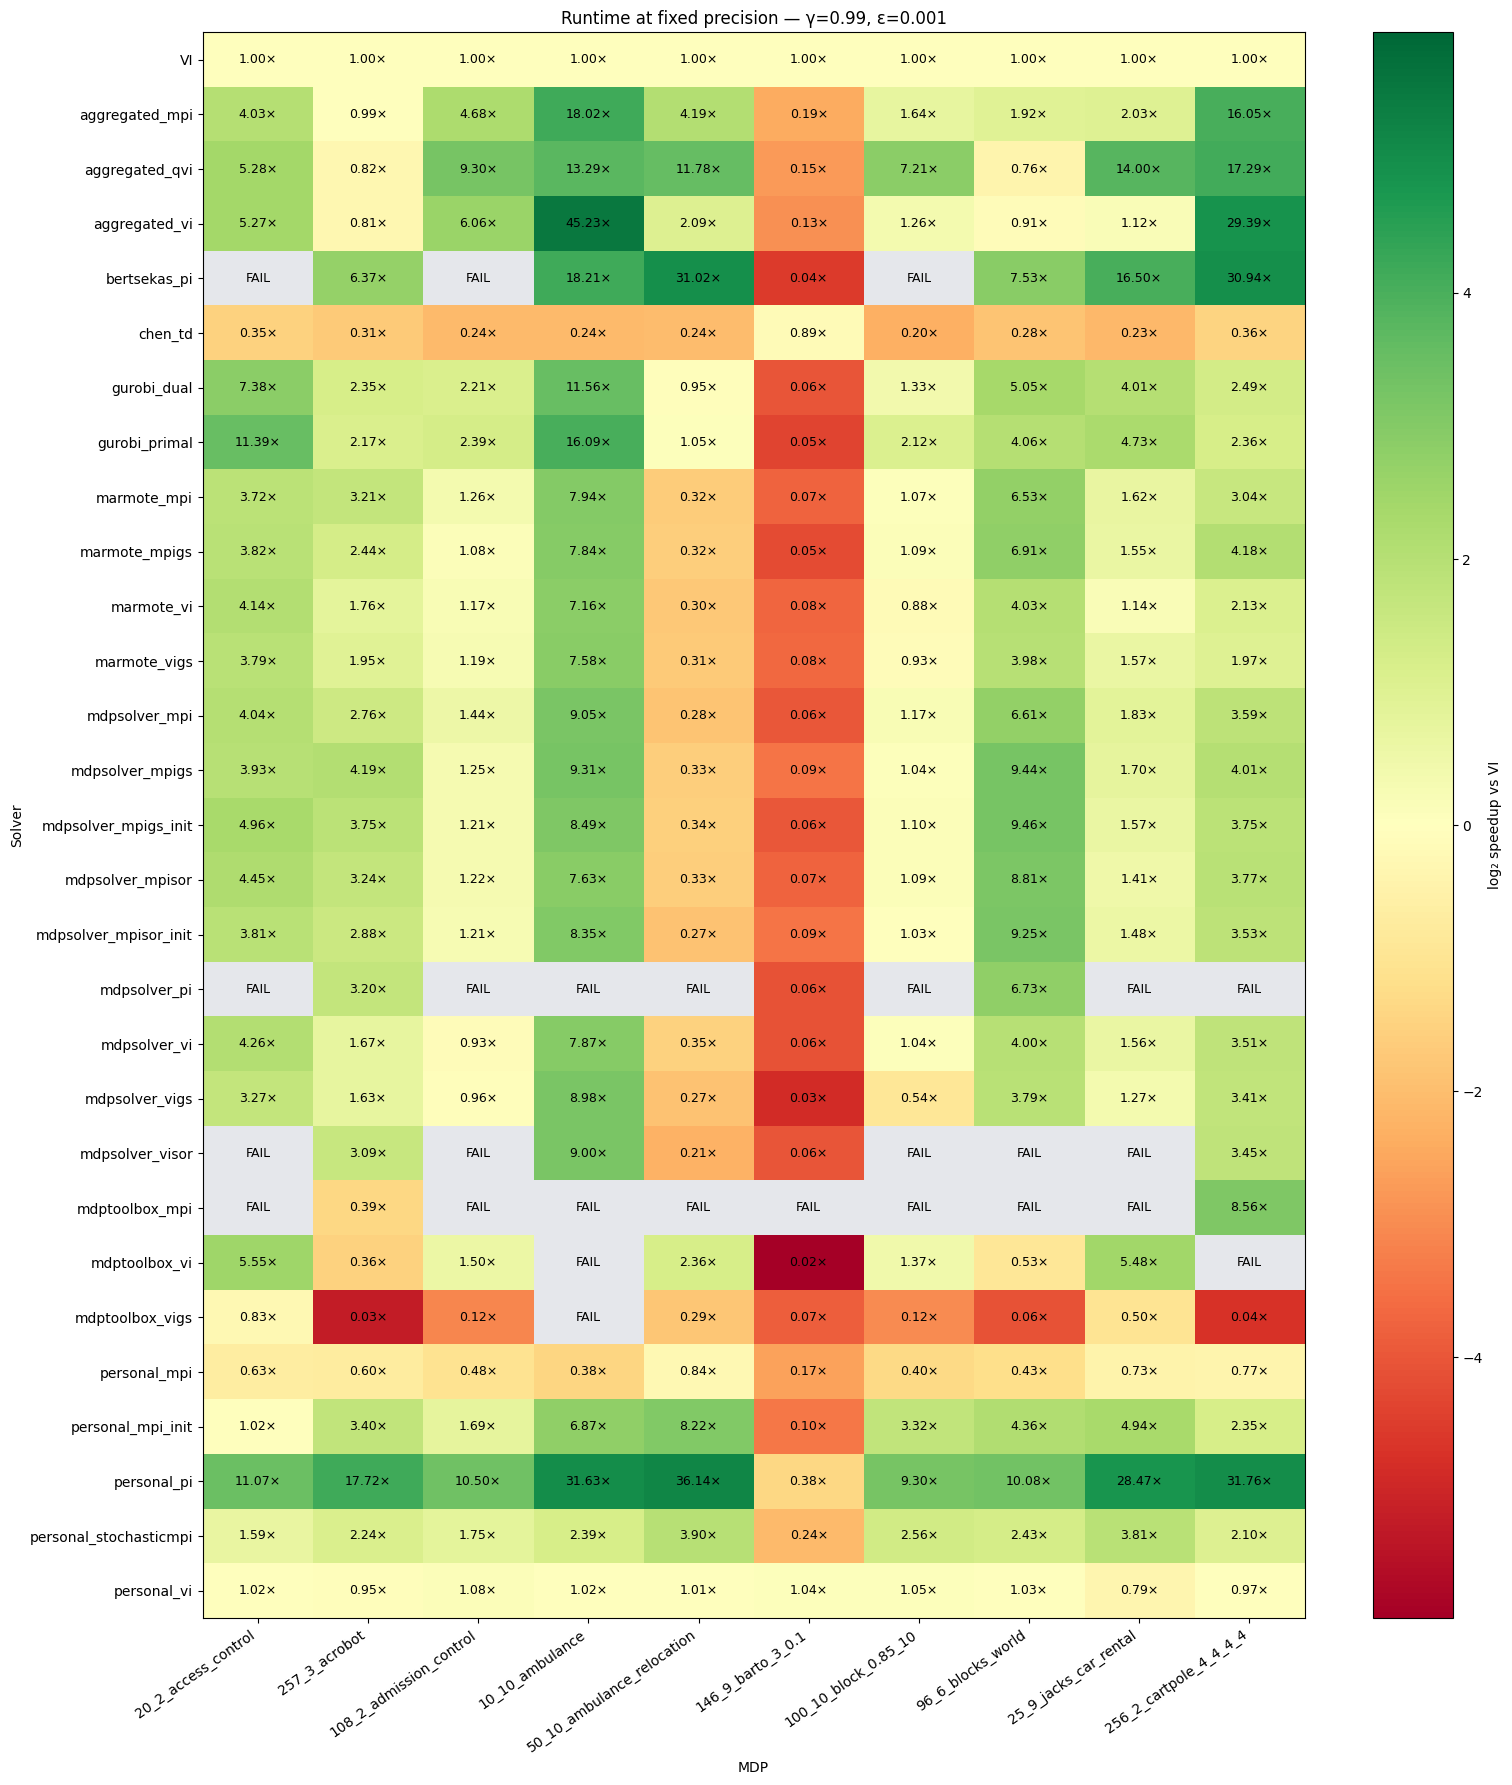

In [ ]:
figure, axes = bench.plot_heat(reference="VI")

In [6]:
assert all(row["status"] == "success" for row in results), results

To compare the full catalogue, replace the model/solver setup cell with:

```python
bench = Benchmark().add_all_models().add_all_solvers()
```

Then rerun the remaining cells. Missing dependencies are reported and skipped. If a solver fails, the quality assertion shows its result and the heatmap marks it as `FAIL`.